In [34]:
import os
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder
from lightgbm import LGBMRanker, plot_importance
from scipy.sparse import csr_matrix
from scipy import sparse
import implicit
from implicit.evaluation import precision_at_k
from implicit.evaluation import ndcg_at_k, ranking_metrics_at_k

ModuleNotFoundError: No module named 'implicit'

In [4]:
##
path = os.path.abspath(os.path.join((os.getcwd()),  os.pardir, "data\\recommendation_dataset.csv")) 
df = pd.read_csv(path)
print(df.shape)
df.head()

(500, 18)


,user_id,age,gender,income,frequency,avg_discount,avg_spend,return_rate,brand,price_segment,style,target_age,brand_purchase_count,recency_days,brand_avg_spend,season,is_sale,label
0,1,36,F,55802,12,48.47,2834.6,0.12,Brand_A,premium,ethnic,35-50,3,159,2005.84,festive,1,1
1,1,36,F,55802,12,48.47,2834.6,0.12,Brand_B,premium,ethnic,25-35,3,42,457.91,festive,0,1
2,1,36,F,55802,12,48.47,2834.6,0.12,Brand_C,mid,ethnic,25-35,1,73,1442.53,summer,1,1
3,1,36,F,55802,12,48.47,2834.6,0.12,Brand_D,mid,casual,35-50,2,64,3681.61,festive,0,1
4,1,36,F,55802,12,48.47,2834.6,0.12,Brand_E,premium,sports,35-50,5,108,2480.13,winter,0,1


In [5]:
df[df["user_id"] == 12]

,user_id,age,gender,income,frequency,avg_discount,avg_spend,return_rate,brand,price_segment,style,target_age,brand_purchase_count,recency_days,brand_avg_spend,season,is_sale,label
110,12,33,M,52683,17,24.95,576.49,0.08,Brand_A,mid,formal,18-25,2,45,3829.01,summer,0,1
111,12,33,M,52683,17,24.95,576.49,0.08,Brand_B,mid,casual,25-35,2,161,3101.56,summer,0,1
112,12,33,M,52683,17,24.95,576.49,0.08,Brand_C,premium,casual,35-50,5,43,3866.41,winter,1,1
113,12,33,M,52683,17,24.95,576.49,0.08,Brand_D,premium,casual,35-50,2,134,1716.97,winter,0,1
114,12,33,M,52683,17,24.95,576.49,0.08,Brand_E,premium,ethnic,18-25,4,44,3520.34,winter,0,1
115,12,33,M,52683,17,24.95,576.49,0.08,Brand_F,low,formal,18-25,5,117,1665.68,summer,1,1
116,12,33,M,52683,17,24.95,576.49,0.08,Brand_G,low,sports,35-50,3,178,3102.92,summer,0,1
117,12,33,M,52683,17,24.95,576.49,0.08,Brand_H,mid,casual,25-35,3,143,2763.15,summer,0,1
118,12,33,M,52683,17,24.95,576.49,0.08,Brand_I,low,sports,25-35,3,42,594.94,festive,1,1
119,12,33,M,52683,17,24.95,576.49,0.08,Brand_J,premium,casual,25-35,0,116,1310.96,summer,0,0


In [6]:
print(f"Total users: {df["user_id"].nunique()}")
print(f"Total items (brands): {df["brand"].nunique()}")

Total users: 50
Total items (brands): 10


In [7]:
#count of unique Brands bought per customer
df_items_per_cust = (
    df.groupby(["user_id"]).agg({"brand": "nunique"}).reset_index()
)
df_items_per_cust.columns = ["CustomerID", "Count_brand_cust"]
df_items_per_cust

,CustomerID,Count_brand_cust
0,1,10
1,2,10
2,3,10
3,4,10
4,5,10
5,6,10
6,7,10
7,8,10
8,9,10
9,10,10


In [8]:
# Simulate timestamp (since synthetic data doesn't have one)
np.random.seed(42)
df["timestamp"] = np.random.randint(1, 100, size=len(df))

In [9]:
# 2. TIME-BASED SPLIT
# ==============================
train = df[df["timestamp"] <= 70]
test = df[df["timestamp"] > 70]

print(train.shape, test.shape)

(365, 19) (135, 19)


In [10]:
# Create user-item matrix
user_encoder = LabelEncoder()
brand_encoder = LabelEncoder()

train["user_idx"] = user_encoder.fit_transform(train["user_id"])
train["brand_idx"] = brand_encoder.fit_transform(train["brand"])

user_item = train.pivot_table(
    index="user_idx",
    columns="brand_idx",
    values="brand_purchase_count",
    fill_value=0
)

user_item

C:\Users\nedwi\AppData\Local\Temp\ipykernel_61336\501537592.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train["user_idx"] = user_encoder.fit_transform(train["user_id"])
C:\Users\nedwi\AppData\Local\Temp\ipykernel_61336\501537592.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train["brand_idx"] = brand_encoder.fit_transform(train["brand"])


brand_idx,0,1,2,3,4,5,6,7,8,9
user_idx,,,,,,,,,,
0,3.0,0.0,1.0,0.0,5.0,1.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,4.0,1.0,0.0,0.0,3.0,5.0,1.0
2,5.0,2.0,0.0,4.0,0.0,1.0,4.0,0.0,4.0,0.0
3,5.0,3.0,0.0,5.0,0.0,0.0,0.0,0.0,1.0,4.0
4,0.0,0.0,1.0,4.0,1.0,1.0,5.0,0.0,2.0,5.0
5,4.0,0.0,3.0,4.0,5.0,0.0,0.0,1.0,0.0,0.0
6,1.0,0.0,0.0,4.0,0.0,2.0,0.0,0.0,4.0,1.0
7,5.0,3.0,0.0,0.0,1.0,5.0,0.0,1.0,0.0,0.0
8,3.0,1.0,0.0,3.0,5.0,0.0,5.0,2.0,0.0,0.0


# Collaborative Filtering

## Implicit CF - SVD - numpy

In [22]:
# Matrix factorization via SVD
U, sigma, Vt = np.linalg.svd(user_item, full_matrices=False)
pred_matrix = np.dot(U, np.dot(np.diag(sigma), Vt))

In [24]:
pred_matrix.shape

(50, 10)

In [25]:
# Predict scores
cf_scores = []
for _, row in test.iterrows():
    try:
        u = user_encoder.transform([row["user_id"]])[0]
        b = brand_encoder.transform([row["brand"]])[0]
        score = pred_matrix[u, b]
    except:
        score = 0
    cf_scores.append(score)

In [26]:
test_cf = test.copy()
test_cf["score"] = cf_scores

In [17]:
#EVALUATION METRIC
# ==============================
def eval_precision_at_k(df, k=3):
    precisions = []
    for user, group in df.groupby("user_id"):
        group = group.sort_values("score", ascending=False)
        top_k = group.head(k)
        precisions.append(top_k["label"].sum() / k)
    return np.mean(precisions)

In [288]:
cf_precision = eval_precision_at_k(test_cf)
cf_precision

0.62

In [37]:
def get_top_n(df, n=3):
    recommendations = (
        df.sort_values(["user_id", "score"], ascending=[True, False])
          .groupby("user_id")
          .head(n)
    )
    return recommendations[["user_id", "brand", "score"]]

In [39]:
top_n_cf = get_top_n(test_cf, n=3)
print("CF Recommendations:")
print(top_n_cf.head(10))

CF Recommendations:
    user_id    brand         score
3         1  Brand_D  3.309108e-15
7         1  Brand_H -2.501241e-15
9         1  Brand_J -4.175793e-15
10        2  Brand_A  1.832060e-14
16        2  Brand_G -6.385440e-15
24        3  Brand_E  6.749146e-15
27        3  Brand_H  4.969396e-15
29        3  Brand_J -1.140587e-14
34        4  Brand_E  4.529249e-15
32        4  Brand_C -1.844045e-15


In [46]:
# Exclude Already Purchased Brands

# Get already purchased brands from train
purchased = train[train["label"] == 1][["user_id", "brand"]]

def remove_seen(df, purchased):
    df = df.merge(purchased, on=["user_id", "brand"], how="left", indicator=True)
    df = df[df["_merge"] == "left_only"]
    return df.drop(columns=["_merge"])

In [54]:
test_cf_filtered = remove_seen(test_cf, purchased)
top_n_cf = get_top_n(test_cf_filtered, 3)
top_n_cf

,user_id,brand,score
1,1,Brand_D,3.309108e-15
3,1,Brand_H,-2.501241e-15
5,1,Brand_J,-4.175793e-15
6,2,Brand_A,1.832060e-14
7,2,Brand_G,-6.385440e-15
...,...,...,...
130,48,Brand_G,-6.424573e-15
131,49,Brand_F,4.964975e-15
132,49,Brand_H,2.603956e-15
133,50,Brand_F,2.728041e-15


In [64]:
top_n_cf.groupby("user_id")["brand"].agg(', '.join).reset_index()

,user_id,brand
0,1,"Brand_D, Brand_H, Brand_J"
1,2,"Brand_A, Brand_G"
2,3,"Brand_E, Brand_H, Brand_J"
3,4,"Brand_E, Brand_C"
4,5,Brand_H
5,6,"Brand_F, Brand_B, Brand_J"
6,7,"Brand_H, Brand_B, Brand_G"
7,8,"Brand_J, Brand_G"
8,9,"Brand_F, Brand_J, Brand_I"
9,10,"Brand_A, Brand_E, Brand_D"


## Implicit CF - ALS - implicit

* This below sparse martrix approach is equivalent to the pandas pivot table done above. 
* Practical difference:
    Pivot → dense, human-readable, pandas-native. 
    Use pivot_table if you want quick exploration or small datasets.
        
    Sparse → memory-efficient, ML-friendly, but less convenient for direct inspection.
    Use CSR sparse matrix if you’re building recommender models or handling large-scale data — it’s the standard input format for algorithms like matrix factorization.                       

In [75]:
df_cust_brand_qty = (
    train.groupby(["user_idx", "brand_idx"])
    .agg({"brand_purchase_count": "sum"})
    .reset_index()
)
df_cust_brand_qty

,user_idx,brand_idx,brand_purchase_count
0,0,0,3
1,0,2,1
2,0,4,5
3,0,5,1
4,1,1,0
...,...,...,...
360,49,3,3
361,49,4,4
362,49,6,3
363,49,8,4


In [76]:
# Create Sparse Matrix
sparse_customer_item = sparse.csr_matrix(
    (
        df_cust_brand_qty["brand_purchase_count"].astype(float),
        (df_cust_brand_qty["user_idx"], df_cust_brand_qty["brand_idx"]), #shape
    ) 
)
sparse_customer_item

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 365 stored elements and shape (50, 10)>

In [78]:
sparse_customer_item.todense()

matrix([[3., 0., 1., 0., 5., 1., 0., 0., 0., 0.],
        [0., 0., 0., 4., 1., 0., 0., 3., 5., 1.],
        [5., 2., 0., 4., 0., 1., 4., 0., 4., 0.],
        [5., 3., 0., 5., 0., 0., 0., 0., 1., 4.],
        [0., 0., 1., 4., 1., 1., 5., 0., 2., 5.],
        [4., 0., 3., 4., 5., 0., 0., 1., 0., 0.],
        [1., 0., 0., 4., 0., 2., 0., 0., 4., 1.],
        [5., 3., 0., 0., 1., 5., 0., 1., 0., 0.],
        [3., 1., 0., 3., 5., 0., 5., 2., 0., 0.],
        [0., 2., 3., 0., 0., 0., 4., 2., 4., 0.],
        [5., 1., 2., 3., 5., 5., 0., 0., 5., 0.],
        [2., 2., 0., 2., 4., 0., 3., 3., 3., 0.],
        [1., 3., 3., 5., 0., 0., 5., 1., 2., 5.],
        [2., 0., 0., 4., 0., 3., 0., 0., 0., 2.],
        [0., 1., 0., 0., 5., 5., 0., 4., 4., 5.],
        [0., 5., 0., 5., 0., 0., 1., 0., 3., 0.],
        [4., 0., 4., 1., 0., 1., 1., 4., 5., 0.],
        [0., 0., 3., 1., 4., 2., 0., 1., 4., 1.],
        [5., 4., 0., 2., 1., 0., 0., 0., 4., 0.],
        [2., 3., 1., 0., 5., 4., 0., 3., 3., 5.],


In [87]:
# Initialize an Alternating Least Squares model
model = implicit.als.AlternatingLeastSquares(factors=20)
# Train on user-item sparse matrix
model.fit(sparse_customer_item)


100%|████████████████████████████████████████████████████████████████████████████████| 15/15 [00:00<00:00, 1562.98it/s]


In [88]:
# R ≈ X . YT

# X∈R 50×20 → user matrix
print(model.user_factors.shape)

# Y∈R 10×20 → item matrix
print(model.item_factors.shape)

(50, 20)
(10, 20)


### Get recommendations

In [232]:
# Get recommendations
user_idx = 0
ids, scores = model.recommend(
    user_idx, sparse_customer_item[user_idx], N=2, filter_already_liked_items=False
)

ids

array([[4, 0],
       [3, 8],
       [0, 6]])

In [133]:
df_brand_desc = train.groupby("brand")[["brand_idx"]].first().reset_index()
print(df_brand_desc)

     brand  brand_idx
0  Brand_A          0
1  Brand_B          1
2  Brand_C          2
3  Brand_D          3
4  Brand_E          4
5  Brand_F          5
6  Brand_G          6
7  Brand_H          7
8  Brand_I          8
9  Brand_J          9


In [134]:
list_brand = df_brand_desc[df_brand_desc["brand_idx"].isin(ids)]["brand"].tolist()
df_recommendations = pd.DataFrame(
    {
        "Brand": list_brand,
        "score": scores,
        "already_liked": np.in1d(ids, sparse_customer_item[cust_id].indices),
    }
)
df_recommendations

,Brand,score,already_liked
0,Brand_A,1.008261,True
1,Brand_E,0.995902,True


In [261]:
user_ids = list(set(test["user_idx"]))
brand_ids, scores = model.recommend(
    user_ids, sparse_customer_item[user_ids], N=3, filter_already_liked_items=False
)


In [285]:
user_list = []
rec_list = []
for i, ids in enumerate(brand_ids):
    user_id = test[test["user_idx"] == i]["user_id"].max()
    list_brand = df_brand_desc[df_brand_desc["brand_idx"].isin(brand_ids[i])]["brand"].tolist()
    user_list.append(user_id)
    rec_list.append(list_brand)

pd.DataFrame([user_list, rec_list]).T

,0,1
0,1,"[Brand_A, Brand_C, Brand_E]"
1,2,"[Brand_D, Brand_H, Brand_I]"
2,3,"[Brand_A, Brand_D, Brand_G]"
3,4,"[Brand_A, Brand_D, Brand_J]"
4,5,"[Brand_D, Brand_G, Brand_J]"
5,6,"[Brand_A, Brand_D, Brand_E]"
6,7,"[Brand_D, Brand_F, Brand_I]"
7,8,"[Brand_A, Brand_B, Brand_F]"
8,9,"[Brand_D, Brand_E, Brand_G]"
9,10,"[Brand_G, Brand_H, Brand_I]"


### Evaluation

In [138]:

test["user_idx"] = user_encoder.transform(test["user_id"])
test["brand_idx"] = brand_encoder.transform(test["brand"])

df_cust_brand_qty_test = (
    test.groupby(["user_idx", "brand_idx"])
    .agg({"brand_purchase_count": "sum"})
    .reset_index()
)
df_cust_brand_qty_test

# Create Sparse Matrix
sparse_customer_item_test = sparse.csr_matrix(
    (
        df_cust_brand_qty_test["brand_purchase_count"].astype(float),
        (df_cust_brand_qty_test["user_idx"], df_cust_brand_qty_test["brand_idx"]), #shape
    ) 
)
sparse_customer_item_test

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 135 stored elements and shape (50, 10)>

In [145]:
def evaluate_model(model, train_matrix, test_matrix, K=10):
    precisions, recalls = [], []
    num_users = train_matrix.shape[0]

    for user_id in range(num_users):
        # Skip users with no test interactions
        if test_matrix[user_id].nnz == 0:
            continue

        # Get recommendations based only on TRAIN interactions
        recommended, _ = model.recommend(
            user_id,
            train_matrix[user_id],
            N=K,
            filter_already_liked_items=True
        )

        # Ground truth: items in TEST split; i.e the brands that user interacted with (purchased)
        test_items = set(test_matrix[user_id].indices)

        # Precision@K
        hits = sum((item in test_items) for item in recommended)    # check if recommended (based on train data) are purchased (in test data)
        precision = hits / K    # purchased / total recommended
        recall = hits / len(test_items)  # purchased / total purchased

        precisions.append(precision)
        recalls.append(recall)

    return np.mean(precisions), np.mean(recalls)

In [146]:
p_at_k, r_at_k = evaluate_model(model, sparse_customer_item, sparse_customer_item_test, K=2)
print(f"Precision@10: {p_at_k:.4f}, Recall@10: {r_at_k:.4f}")

Precision@10: 0.9100, Recall@10: 0.7787


In [149]:
def ndcg_at_k(recommended, test_items, k=10):
    """
    Compute NDCG@k for a single user.
    recommended: list of recommended item IDs
    test_items: set of ground-truth item IDs from test split
    """
    dcg = 0.0
    for i, item in enumerate(recommended[:k]):
        if item in test_items:
            dcg += 1 / np.log2(i + 2)  # rank position is i+1, so use i+2 in denominator

    # Ideal DCG: all relevant items ranked at the top
    ideal_hits = min(len(test_items), k)
    idcg = sum(1 / np.log2(i + 2) for i in range(ideal_hits))

    return dcg / idcg if idcg > 0 else 0.0


def evaluate_model_ndcg(model, train_matrix, test_matrix, K=10):
    ndcgs = []
    num_users = train_matrix.shape[0]

    for user_id in range(num_users):
        if test_matrix[user_id].nnz == 0:
            continue

        # get recommendations for user
        recommended, _ = model.recommend(
            user_id,
            train_matrix[user_id],
            N=K,
            filter_already_liked_items=True
        )

        #
        test_items = set(test_matrix[user_id].indices)
        ndcgs.append(ndcg_at_k(recommended, test_items, k=K))

    return np.mean(ndcgs)


# Example usage
ndcg_score = evaluate_model_ndcg(model, sparse_customer_item, sparse_customer_item_test, K=2)
print(f"NDCG@10: {ndcg_score:.4f}")

NDCG@10: 1.0000


In [ ]:
precision_at_k(model, sparse_customer_item, sparse_customer_item_test, K=2)
ndcg_at_k(model, sparse_customer_item, sparse_customer_item_test, K=2)
# not working

# Content based filtering

In [301]:
# Encode brand features
brand_features = (
    train.groupby("brand")[["price_segment", "style", "target_age"]]
    .agg(lambda x: x.mode()[0])
)

brand_features = pd.get_dummies(brand_features)
brand_features.head()

,price_segment_low,price_segment_mid,price_segment_premium,style_casual,style_ethnic,style_formal,style_sports,target_age_18-25,target_age_25-35,target_age_35-50
brand,,,,,,,,,,
Brand_A,False,False,True,False,False,True,False,False,True,False
Brand_B,True,False,False,False,False,False,True,False,False,True
Brand_C,True,False,False,True,False,False,False,False,False,True
Brand_D,True,False,False,True,False,False,False,False,True,False
Brand_E,True,False,False,True,False,False,False,False,False,True


In [304]:
brand_sim = cosine_similarity(brand_features)
brand_sim_df = pd.DataFrame(brand_sim, index=brand_features.index, columns=brand_features.index)
brand_sim_df

brand,Brand_A,Brand_B,Brand_C,Brand_D,Brand_E,Brand_F,Brand_G,Brand_H,Brand_I,Brand_J
brand,,,,,,,,,,
Brand_A,1.000000,0.000000,0.000000,0.333333,0.000000,0.333333,0.000000,0.333333,0.333333,0.666667
Brand_B,0.000000,1.000000,0.666667,0.333333,0.666667,0.333333,0.333333,0.000000,0.666667,0.000000
Brand_C,0.000000,0.666667,1.000000,0.666667,1.000000,0.000000,0.333333,0.000000,0.333333,0.000000
Brand_D,0.333333,0.333333,0.666667,1.000000,0.666667,0.000000,0.333333,0.000000,0.666667,0.333333
Brand_E,0.000000,0.666667,1.000000,0.666667,1.000000,0.000000,0.333333,0.000000,0.333333,0.000000
Brand_F,0.333333,0.333333,0.000000,0.000000,0.000000,1.000000,0.333333,0.333333,0.333333,0.333333
Brand_G,0.000000,0.333333,0.333333,0.333333,0.333333,0.333333,1.000000,0.333333,0.333333,0.333333
Brand_H,0.333333,0.000000,0.000000,0.000000,0.000000,0.333333,0.333333,1.000000,0.000000,0.000000
Brand_I,0.333333,0.666667,0.333333,0.666667,0.333333,0.333333,0.333333,0.000000,1.000000,0.333333


In [305]:
# Build user profile (average of purchased brands)
user_profiles = {}
for user, group in train[train["label"] == 1].groupby("user_id"):
    brands = group["brand"]
    vectors = brand_features.loc[brands]
    user_profiles[user] = vectors.mean().values

In [310]:
user_profiles[1]

array([0.5 , 0.  , 0.5 , 0.5 , 0.  , 0.25, 0.25, 0.25, 0.25, 0.5 ])

In [311]:
# Score
cb_scores = []
for _, row in test.iterrows():
    user = row["user_id"]
    brand = row["brand"]
    
    if user in user_profiles and brand in brand_features.index:
        user_vec = user_profiles[user]
        brand_vec = brand_features.loc[brand].values
        score = cosine_similarity([user_vec], [brand_vec])[0][0]
    else:
        score = 0
    
    cb_scores.append(score)


In [313]:
test_cb = test.copy()
test_cb["score"] = cb_scores

cb_precision = eval_precision_at_k(test_cb)
cb_precision

0.6333333333333333

# LightGBM Ranker

In [2]:
from lightgbm import LGBMRanker
import os
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder
from scipy.sparse import csr_matrix

In [11]:
# Encode categorical features
cat_cols = ["brand", "price_segment", "style", "target_age", "season", "gender"]

for col in cat_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])
    test[col] = le.transform(test[col])


C:\Users\nedwi\AppData\Local\Temp\ipykernel_61336\3566349335.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train[col] = le.fit_transform(train[col])
C:\Users\nedwi\AppData\Local\Temp\ipykernel_61336\3566349335.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test[col] = le.transform(test[col])
C:\Users\nedwi\AppData\Local\Temp\ipykernel_61336\3566349335.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value i

In [30]:
features = [
    "age","income","frequency","avg_discount","avg_spend","return_rate",
    "brand","price_segment","style","target_age",
    "brand_purchase_count","recency_days","brand_avg_spend",
    "season","is_sale"
]

X_train = train[features]
y_train = train["label"]
X_test = test[features]
y_test = test["label"]

In [14]:
# Group by user
group = train.groupby("user_id").size().values
group

array([4, 8, 7, 8, 9, 6, 7, 8, 6, 5, 7, 8, 8, 6, 7, 5, 8, 9, 5, 8, 6, 9,
       6, 8, 8, 6, 7, 7, 7, 8, 7, 5, 9, 8, 9, 8, 7, 6, 7, 9, 8, 9, 6, 8,
       9, 7, 9, 7, 8, 8])

In [15]:
# creates pairwise comparisons inside each group

#the only objective which is available for Ranking in LightGBM is lambdarank and LambdaMART is the boosted tree version of LambdaRank. 
#So, In essence lambdarank objective along with gbdt boosting_type is what LambdaMART is.
model = LGBMRanker(objective="lambdarank", boosting_type="gbdt")
model.fit(X_train, y_train, group=group)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000131 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 477
[LightGBM] [Info] Number of data points in the train set: 365, number of used features: 15
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positi

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,'lambdarank'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

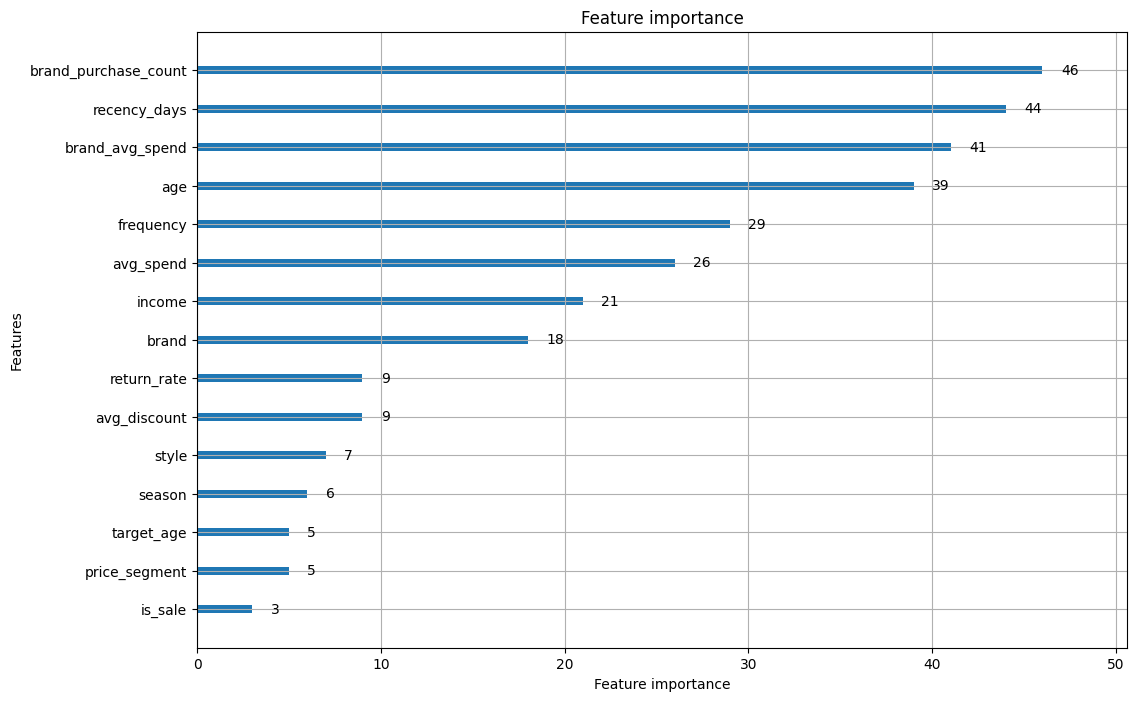

In [35]:
plot_importance(model, figsize = (12,8))

In [46]:
# Predict
test_lgb = test.copy()
test_lgb["score"] = model.predict(X_test)


In [96]:
test_lgb.head(10)

,user_id,age,gender,income,frequency,avg_discount,avg_spend,return_rate,brand,price_segment,style,target_age,brand_purchase_count,recency_days,brand_avg_spend,season,is_sale,label,timestamp,score
1,1,36,0,55802,12,48.47,2834.60,0.12,1,2,1,1,3,42,457.91,0,0,1,93,4.083479
3,1,36,0,55802,12,48.47,2834.60,0.12,3,1,0,2,2,64,3681.61,0,0,1,72,4.083479
6,1,36,0,55802,12,48.47,2834.60,0.12,6,1,1,0,3,73,2715.85,1,1,1,83,4.083479
7,1,36,0,55802,12,48.47,2834.60,0.12,7,1,0,1,0,111,2463.09,1,1,0,87,-4.083479
8,1,36,0,55802,12,48.47,2834.60,0.12,8,0,3,1,4,179,3521.71,2,1,1,75,4.083479
9,1,36,0,55802,12,48.47,2834.60,0.12,9,2,3,0,5,102,1602.72,1,0,1,75,4.083479
10,2,20,0,47768,1,21.65,3867.89,0.43,0,2,2,0,5,80,2551.50,0,1,1,88,4.083479
16,2,20,0,47768,1,21.65,3867.89,0.43,6,0,1,2,2,69,729.12,2,1,1,88,4.083479
24,3,46,1,113908,9,19.82,4391.52,0.38,4,0,3,1,0,66,1012.60,2,1,0,76,-4.083479
27,3,46,1,113908,9,19.82,4391.52,0.38,7,1,3,0,1,63,415.82,1,0,1,89,4.083479


In [97]:
test_lgb["score"].unique()

#These are ranking scores.
#They are:
    #Not probabilities
   # Not calibrated
   # Not bounded between 0 and 1

#Only the ordering matters.

array([ 4.08347857,  4.08347856,  4.08347858, -4.08347855,  4.08347855,
        4.08347857,  4.08347853,  4.08347852, -4.08347857,  4.08347856,
       -4.08347856, -4.08347857,  4.08347855,  4.08347851,  4.08347859,
        4.08347856,  4.08347857,  4.08347855,  4.08347858,  4.08347858,
        4.08347854, -4.08347855,  4.08347855,  4.0834786 ,  4.08347858,
       -4.08347857,  4.08347855,  4.08347857,  4.08347857,  4.08347856,
        4.0834786 ,  4.08347857, -4.08347855,  4.08347857,  4.08347856,
        4.08347859,  4.08347856,  4.08347856,  4.08347859,  4.08347857,
        4.08347858, -4.08347853, -4.08347854, -4.08347853, -4.08347854,
        4.08347857,  4.0834786 ,  4.0834786 ,  4.08347861, -4.08347855,
        4.08347861,  4.08347853,  4.08347853,  4.08347856,  4.08347854,
        4.08347851,  4.08347854,  4.08347854,  4.08347853,  4.08347856,
        4.08347858,  4.08347858, -4.08347857,  4.08347857,  4.08347858,
        4.08347857,  4.08347854,  4.08347853,  4.08347854,  4.08

In [45]:
lgb_precision = eval_precision_at_k(test_lgb)
lgb_precision

np.float64(0.6466666666666666)

In [47]:
def ndcg(y_score, y_true, k):
   order = np.argsort(y_score)[::-1]
   y_true = np.take(y_true, order[:k])

   gain = 2 ** y_true - 1
   discounts = np.log2(np.arange(len(y_true)) + 2)
   return np.sum(gain / discounts)

In [65]:
ndcg_ = list()
qids = np.unique(test["user_id"])

for i, uid in enumerate(qids):
   y = test[test["user_id"] == uid]["label"]
    
   if np.sum(y) == 0:
      continue
    
   p = model.predict(test[test["user_id"] == uid][features])
   y = np.array(y) 
   idcg = ndcg(y, y, k=3)
   ndcg_.append(ndcg(p, y, k=3) / idcg)


#A higher NDCG score indicates a higher ranking quality.
print(np.mean(ndcg_))

1.0


In [99]:
def get_top_n(df, n=3):
    recommendations = (
        df.sort_values(["user_id", "score"], ascending=[True, False])
          .groupby("user_id")
          .head(n)
    )
    return recommendations[["user_id", "brand", "score"]]

In [100]:
top_n_lgb = get_top_n(test_lgb, n=3)
print("LightGBM Recommendations:")
print(top_n_lgb.head(10))

LightGBM Recommendations:
    user_id  brand     score
6         1      6  4.083479
1         1      1  4.083479
9         1      9  4.083479
10        2      0  4.083479
16        2      6  4.083479
27        3      7  4.083479
29        3      9 -4.083479
24        3      4 -4.083479
34        4      4  4.083479
32        4      2 -4.083479


In [86]:
model.predict(test[test["user_id"] == 50][features])

array([4.08347855, 4.08347858])

In [78]:
ff = features + ["label"]
test[test["user_id"] == 1][ff]

,age,income,frequency,avg_discount,avg_spend,return_rate,brand,price_segment,style,target_age,brand_purchase_count,recency_days,brand_avg_spend,season,is_sale,label
1,36,55802,12,48.47,2834.6,0.12,1,2,1,1,3,42,457.91,0,0,1
3,36,55802,12,48.47,2834.6,0.12,3,1,0,2,2,64,3681.61,0,0,1
6,36,55802,12,48.47,2834.6,0.12,6,1,1,0,3,73,2715.85,1,1,1
7,36,55802,12,48.47,2834.6,0.12,7,1,0,1,0,111,2463.09,1,1,0
8,36,55802,12,48.47,2834.6,0.12,8,0,3,1,4,179,3521.71,2,1,1
9,36,55802,12,48.47,2834.6,0.12,9,2,3,0,5,102,1602.72,1,0,1


In [104]:
test[test["user_id"] == 1].head(20)

,user_id,age,gender,income,frequency,avg_discount,avg_spend,return_rate,brand,price_segment,style,target_age,brand_purchase_count,recency_days,brand_avg_spend,season,is_sale,label,timestamp
1,1,36,0,55802,12,48.47,2834.6,0.12,1,2,1,1,3,42,457.91,0,0,1,93
3,1,36,0,55802,12,48.47,2834.6,0.12,3,1,0,2,2,64,3681.61,0,0,1,72
6,1,36,0,55802,12,48.47,2834.6,0.12,6,1,1,0,3,73,2715.85,1,1,1,83
7,1,36,0,55802,12,48.47,2834.6,0.12,7,1,0,1,0,111,2463.09,1,1,0,87
8,1,36,0,55802,12,48.47,2834.6,0.12,8,0,3,1,4,179,3521.71,2,1,1,75
9,1,36,0,55802,12,48.47,2834.6,0.12,9,2,3,0,5,102,1602.72,1,0,1,75


In [105]:
train[train["user_id"] == 1].head(20)

,user_id,age,gender,income,frequency,avg_discount,avg_spend,return_rate,brand,price_segment,...,target_age,brand_purchase_count,recency_days,brand_avg_spend,season,is_sale,label,timestamp,user_idx,brand_idx
0,1,36,0,55802,12,48.47,2834.6,0.12,0,2,...,2,3,159,2005.84,0,1,1,52,0,0
2,1,36,0,55802,12,48.47,2834.6,0.12,2,1,...,1,1,73,1442.53,1,1,1,15,0,2
4,1,36,0,55802,12,48.47,2834.6,0.12,4,2,...,2,5,108,2480.13,2,0,1,61,0,4
5,1,36,0,55802,12,48.47,2834.6,0.12,5,2,...,1,1,62,3142.76,2,1,1,21,0,5
